In [13]:
# Core Qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector

# Circuits / ansatz (si tu en as vraiment besoin)
from qiskit.circuit.library import EvolvedOperatorAnsatz

# Qiskit Nature (second_q)
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

# Algorithms (Qiskit Algorithms)
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

# Plotting (optionnel)
import matplotlib.pyplot as plt
from qiskit_nature.second_q.circuit.library import HartreeFock , UCCSD

from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import SLSQP

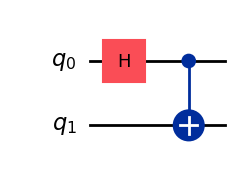

In [2]:
qr=QuantumCircuit(2)
qr.h(0)
qr.cx(0,1)
qr.draw(output='mpl')

In [3]:
state=Statevector.from_instruction(qr)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [4]:
driver=PySCFDriver(atom="H 0 0 0; H 0 0 0.735",basis="sto3g",charge=0,spin=0,unit=DistanceUnit.ANGSTROM)#initialize the driver for the H2 molecule 

In [5]:
problem=driver.run()
print(problem)

In [6]:
print(f"There is {problem.num_particles} electrons in the system.")
print(f"There are {problem.num_spatial_orbitals} spatial orbitals in the system.")
print(f"There are {problem.num_spin_orbitals} spin orbitals in the system.")


There is (1, 1) electrons in the system.
There are 2 spatial orbitals in the system.
There are 4 spin orbitals in the system.


In [10]:
solver = GroundStateEigensolver(
    JordanWignerMapper(),
    VQEigensolver(ansatz=EvolvedOperatorAnsatz(problem.hamiltonian, HartreeFock(problem.num_particles, problem.num_spatial_orbitals)))  
)

result = solver.solve(problem)
print(result)

NameError: name 'VQEigensolver' is not defined

In [9]:
print("HF energy:", result.hartree_fock_energy)


HF energy: -1.116998996754004


In [15]:
print(problem.num_spatial_orbitals)
print(problem.num_particles)


2
(1, 1)


In [21]:

mapper = JordanWignerMapper()
initial_state_circuit = HartreeFock(
    2,
    (1,1),
    mapper,
)
ansatz = UCCSD(
                problem.num_spatial_orbitals,
                problem.num_particles,
                mapper,
                initial_state=initial_state_circuit,
            )

In [22]:
print(ansatz.num_qubits)

4


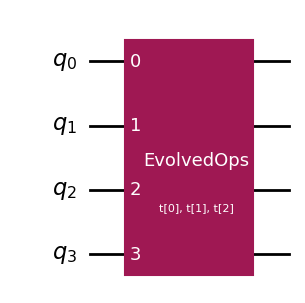

In [23]:
ansatz.draw(output='mpl')

In [ ]:


hf_circuit = HartreeFock(
    2,
    (1,1),
    mapper,
)

print(hf_circuit)

     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
q_3: ─────
          


In [19]:
print(hf_circuit.num_qubits)


8


In [20]:
print(problem.num_spin_orbitals)


4
